# H5 Database Testing Notebook

Test the H5 database built by (2)wsi_preprocessing.ipynb and injected with tumor_mask by (3)annotation_tile_visualization.ipynb.

**Test Scope:**
1. Browse H5 metadata (datasets / attributes)
2. Tissue mask visualization (overlay on WSI thumbnail)
3. Tumor-region visualization at tile-grid level
   - Full-WSI overview
   - Cropped tumor-region browsing (paired with real tissue images)


In [ ]:
import numpy as np
import h5py
import openslide
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path

print(f"openslide : {openslide.__version__}")

# Enable Chinese font support in matplotlib
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


openslide : 1.4.1


In [ ]:
# --- Tunable Parameters ------------------------------------------------------
SLIDE_ID    = "tumor_011"
CONTEXT_PAD = 10       # Additional tile rows/cols shown around tumor regions
CLUSTER_GAP = 30       # Distance threshold (in tile count) to separate tumor regions

# --- Paths ------------------------------------------------------------------
SLIDE_DIR = Path("data/camelyon16/training/tumor")
H5_DIR    = Path("tile_database")

slide_path = SLIDE_DIR / f"{SLIDE_ID}.tif"
h5_path    = H5_DIR    / f"{SLIDE_ID}.h5"

for p, label in [(slide_path, "slide"), (h5_path, "h5")]:
    assert p.exists(), f"{label} not found: {p}"
    print(f"  {label:6s} : {p}")


  slide  : data\camelyon16\training\tumor\tumor_011.tif
  h5     : tile_database\tumor_011.h5


## 1. Browse H5 Metadata

List shapes / dtypes of all datasets and all attributes.


In [ ]:
with h5py.File(h5_path, 'r') as f:
    print(f"=== {h5_path.name} ===")
    print()
    print("-- Attributes --")
    for k, v in f.attrs.items():
        print(f"  {k:22s} = {v}")
    print()
    print("-- Datasets --")
    for k in sorted(f.keys()):
        ds = f[k]
        print(f"  {k:28s}  shape={str(ds.shape):18s}  dtype={ds.dtype}")
    print()

    # Basic statistics
    tissue = f['tissue_mask'][:]
    tumor  = f['tumor_mask'][:]
    N = len(tissue)
    print(f"-- Summary --")
    print(f"  Total tiles    : {N}")
    print(f"  Tissue tiles   : {tissue.sum()} ({tissue.sum()/N*100:.1f}%)")
    print(f"  Tumor tiles    : {tumor.sum()} ({tumor.sum()/N*100:.1f}%)")
    print(f"  Slide dims     : {tuple(f.attrs['slide_dimensions'])}")
    print(f"  Tile size (px) : {f.attrs['tile_size']}")
    print(f"  Level 20x      : {f.attrs['level_20x']}")
    print(f"  Level 10x      : {f.attrs['level_10x']}")
    print(f"  MPP            : {f.attrs['mpp']:.6f}")


=== tumor_011.h5 ===

-- Attributes --
  level_10x              = 2
  level_20x              = 1
  mpp                    = 0.24309399999999998
  slide_dimensions       = [ 97792 221184]
  tile_size              = 224

-- Datasets --
  coords                        shape=(107474, 2)         dtype=int32
  embeddings_10x_i              shape=(107474, 512)       dtype=float32
  embeddings_10x_s              shape=(107474, 512)       dtype=float32
  embeddings_20x_i              shape=(107474, 512)       dtype=float32
  embeddings_20x_s              shape=(107474, 512)       dtype=float32
  thumbnail                     shape=(3456, 1528, 3)     dtype=uint8
  thumbnail_embedding_i         shape=(512,)              dtype=float32
  thumbnail_embedding_s         shape=(512,)              dtype=float32
  tissue_mask                   shape=(107474,)           dtype=bool
  tumor_mask                    shape=(107474,)           dtype=bool

-- Summary --
  Total tiles    : 107474
  Tissue tiles 

## 2. Tissue Mask Visualization

Reshape `tissue_mask` and `tumor_mask` into 2D grids and overlay them on the WSI thumbnail.


In [ ]:
# --- Load H5 Data ------------------------------------------------------------
with h5py.File(h5_path, 'r') as f:
    coords      = f['coords'][:]         # (N, 2) int32, level-0 (x, y)
    tissue_mask = f['tissue_mask'][:]     # (N,) bool
    tumor_mask  = f['tumor_mask'][:]      # (N,) bool
    thumbnail   = f['thumbnail'][:]       # (H, W, 3) uint8
    tile_size   = int(f.attrs['tile_size'])
    level_20x   = int(f.attrs['level_20x'])
    slide_dims  = tuple(f.attrs['slide_dimensions'])  # (W, H) at level-0

N = len(coords)

# Tile-grid shape
xs_unique = np.sort(np.unique(coords[:, 0]))
ys_unique = np.sort(np.unique(coords[:, 1]))
n_cols = len(xs_unique)
n_rows = len(ys_unique)
tile_size_l0 = int(xs_unique[1] - xs_unique[0]) if len(xs_unique) > 1 else tile_size

print(f"Loaded {h5_path.name}:")
print(f"  N={N}, grid={n_cols}x{n_rows}, tile_size={tile_size}, tile_l0={tile_size_l0}")
print(f"  slide_dims={slide_dims}, level_20x={level_20x}")
print(f"  tissue={tissue_mask.sum()}, tumor={tumor_mask.sum()}")


Loaded tumor_011.h5:
  N=107474, grid=218x493, tile_size=224, tile_l0=448
  slide_dims=(np.int64(97792), np.int64(221184)), level_20x=1
  tissue=24347, tumor=1233


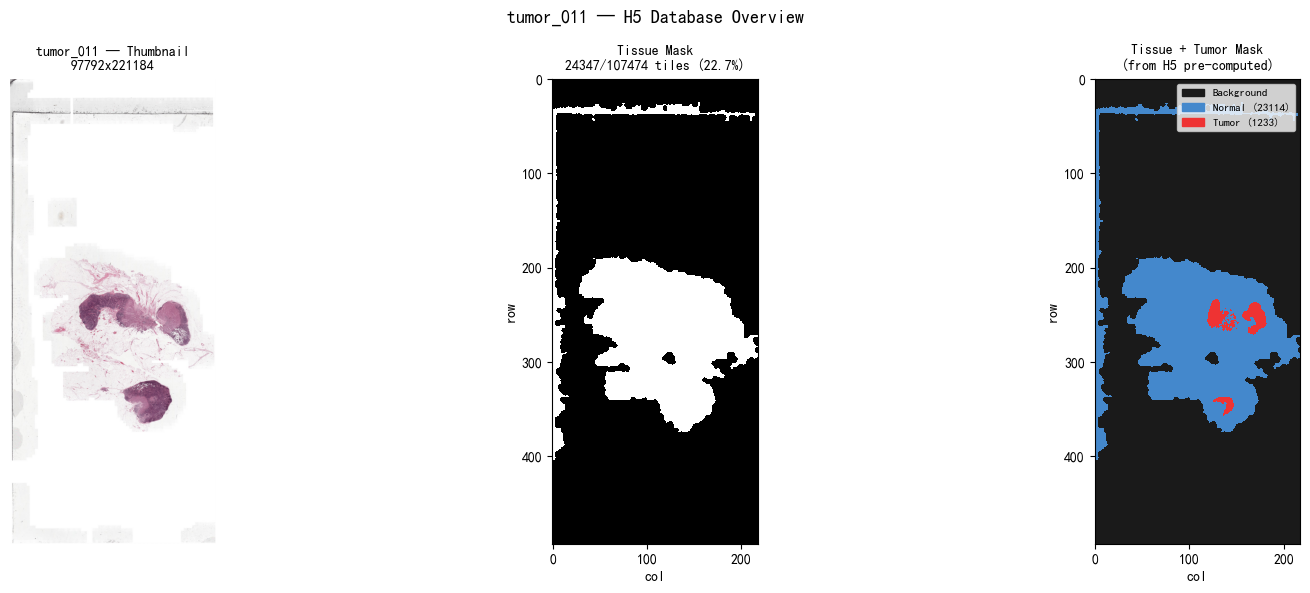

In [ ]:
# Reshape to 2D grids
tissue_grid = tissue_mask.reshape(n_rows, n_cols)
tumor_grid  = tumor_mask.reshape(n_rows, n_cols)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: thumbnail
axes[0].imshow(thumbnail)
axes[0].set_title(f"{SLIDE_ID} — Thumbnail\n{slide_dims[0]}x{slide_dims[1]}", fontsize=10)
axes[0].axis('off')

# Middle: tissue mask
axes[1].imshow(tissue_grid, cmap='gray', interpolation='nearest')
axes[1].set_title(f"Tissue Mask\n{tissue_mask.sum()}/{N} tiles "
                  f"({tissue_mask.sum()/N*100:.1f}%)", fontsize=10)
axes[1].set_xlabel("col")
axes[1].set_ylabel("row")

# Right: three-class overlay (background/normal/tumor)
grid_display = np.zeros((n_rows, n_cols), dtype=np.int32)
grid_display[tissue_grid] = 1
grid_display[tumor_grid]  = 2

cmap3 = ListedColormap(['#1a1a1a', '#4488cc', '#ee3333'])
axes[2].imshow(grid_display, cmap=cmap3, vmin=0, vmax=2, interpolation='nearest')
legend_handles = [
    mpatches.Patch(color='#1a1a1a', label='Background'),
    mpatches.Patch(color='#4488cc', label=f'Normal ({int((tissue_grid & ~tumor_grid).sum())})'),
    mpatches.Patch(color='#ee3333', label=f'Tumor ({int(tumor_grid.sum())})'),
]
axes[2].legend(handles=legend_handles, fontsize=8, loc='upper right')
axes[2].set_title(f"Tissue + Tumor Mask\n(from H5 pre-computed)", fontsize=10)
axes[2].set_xlabel("col")
axes[2].set_ylabel("row")

fig.suptitle(f"{SLIDE_ID} — H5 Database Overview", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Tumor Region Visualization at Tile-Grid Level

### 3.1 Full WSI Overview

Display the full-WSI tile grid in three colors (black=background, blue-gray=normal tissue, red=tumor tile).


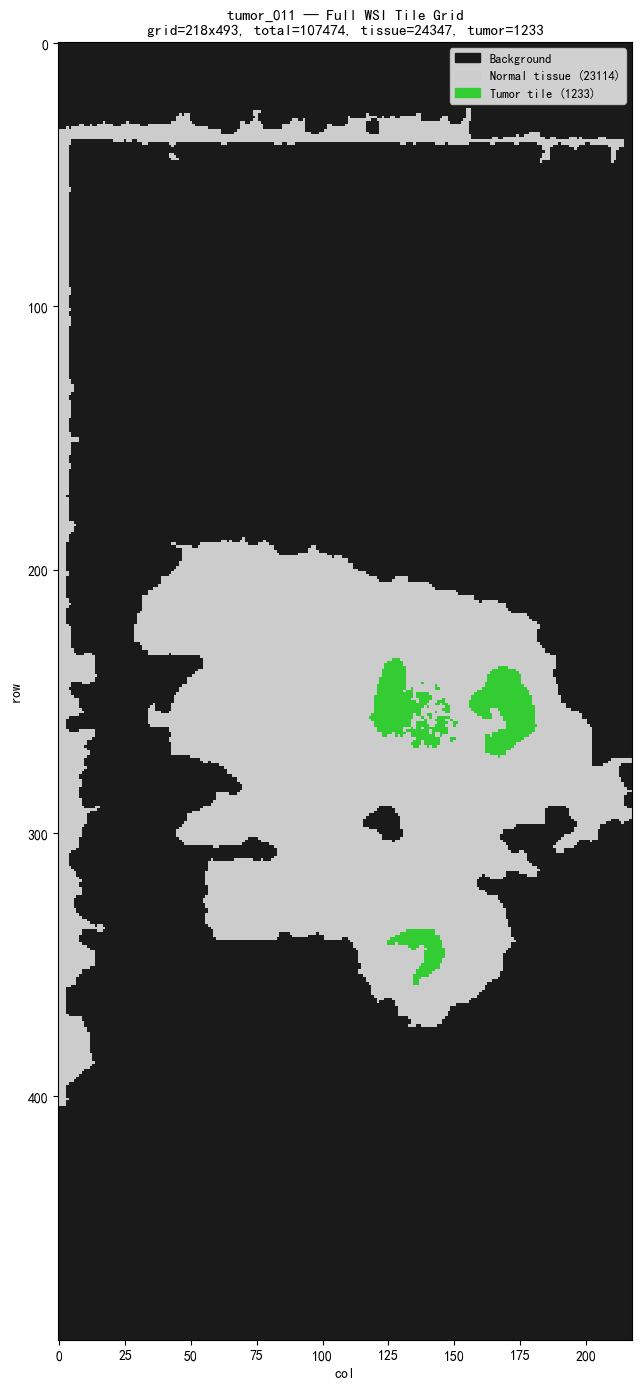

In [ ]:
# Full-WSI tile-grid visualization in three colors
grid_display = np.zeros((n_rows, n_cols), dtype=np.int32)
grid_display[tissue_grid] = 1
grid_display[tumor_grid]  = 2

aspect = n_cols / max(n_rows, 1)
fig_h = max(5, min(14, n_rows * 0.04))
fig_w = max(8, min(20, fig_h * aspect + 2))

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
cmap3 = ListedColormap(['#1a1a1a', '#cccccc', '#33cc33'])
ax.imshow(grid_display, cmap=cmap3, vmin=0, vmax=2, interpolation='nearest')

legend_handles = [
    mpatches.Patch(color='#1a1a1a', label='Background'),
    mpatches.Patch(color='#cccccc', label=f'Normal tissue ({int((tissue_grid & ~tumor_grid).sum())})'),
    mpatches.Patch(color='#33cc33', label=f'Tumor tile ({int(tumor_grid.sum())})'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right')
ax.set_xlabel("col")
ax.set_ylabel("row")
ax.set_title(f"{SLIDE_ID} — Full WSI Tile Grid\n"
             f"grid={n_cols}x{n_rows}, total={N}, "
             f"tissue={tissue_mask.sum()}, tumor={tumor_mask.sum()}", fontsize=11)
plt.tight_layout()
plt.show()


### 3.2 Cropped Tumor-Region Browsing

Automatically cluster independent tumor regions. For each region, output:
- **Figure A**: color-block grid (background / normal / tumor)
- **Figure B**: real 20x tissue image (tumor kept in original color, normal slightly dimmed, background black)


Found 2 tumor cluster(s)


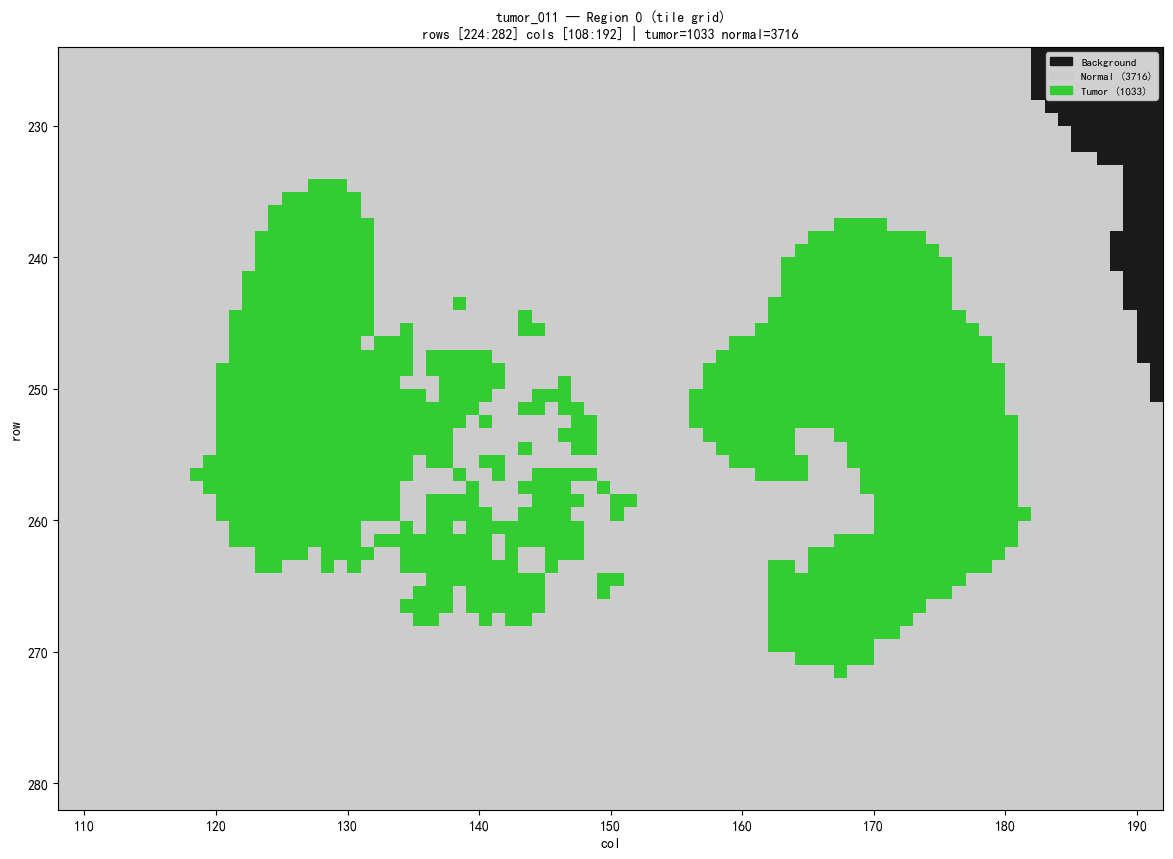

  Region 0: reading 58x84 tiles ...


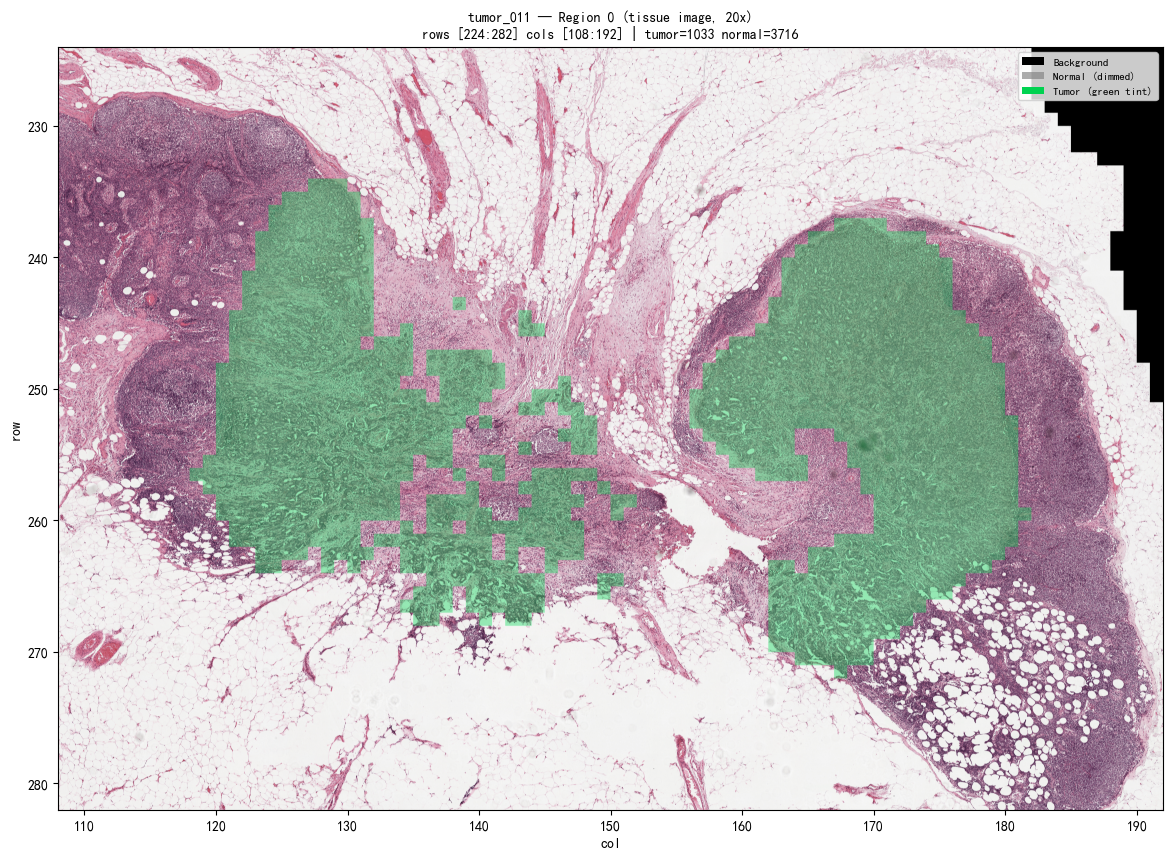

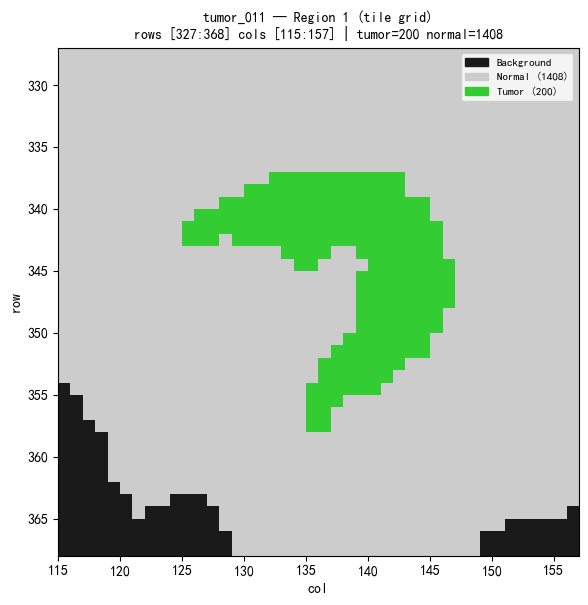

  Region 1: reading 41x42 tiles ...


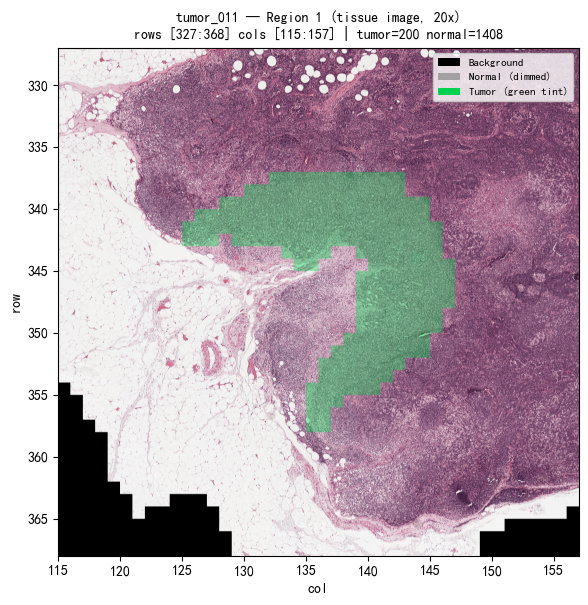

In [ ]:
def cluster_tumor_regions(tumor_mask_grid, context_pad, cluster_gap):
    '''Cluster tumor tiles into independent regions.'''
    n_rows, n_cols = tumor_mask_grid.shape
    kernel = np.ones((cluster_gap, cluster_gap), np.uint8)
    dilated = cv2.dilate(tumor_mask_grid.astype(np.uint8), kernel, iterations=1)
    n_labels, labels = cv2.connectedComponents(dilated)

    regions = []
    for label_id in range(1, n_labels):
        mask_in_cluster = tumor_mask_grid & (labels == label_id)
        if not mask_in_cluster.any():
            continue
        t_ys, t_xs = np.where(mask_in_cluster)
        r_min = max(0, t_ys.min() - context_pad)
        r_max = min(n_rows, t_ys.max() + context_pad + 1)
        c_min = max(0, t_xs.min() - context_pad)
        c_max = min(n_cols, t_xs.max() + context_pad + 1)
        regions.append((slice(r_min, r_max), slice(c_min, c_max)))
    return regions


def plot_regions(tumor_mask, tissue_mask, n_rows, n_cols,
                 coords, tile_size_l0, context_pad, cluster_gap, slide_id,
                 slide_path, level_20x, tile_size):
    '''Crop and visualize each tumor region: grid + tissue image.'''
    tumor_grid  = tumor_mask.reshape(n_rows, n_cols)
    tissue_grid = tissue_mask.reshape(n_rows, n_cols)

    grid_display = np.zeros((n_rows, n_cols), dtype=np.int32)
    grid_display[tissue_grid] = 1
    grid_display[tumor_grid]  = 2

    regions = cluster_tumor_regions(tumor_grid, context_pad, cluster_gap)
    if not regions:
        print("No tumor regions found.")
        return

    print(f"Found {len(regions)} tumor cluster(s)")

    slide = openslide.OpenSlide(str(slide_path))

    for idx, (rslice, cslice) in enumerate(regions):
        sub = grid_display[rslice, cslice]
        sub_rows, sub_cols = sub.shape
        n_tumor_sub  = int((sub == 2).sum())
        n_normal_sub = int((sub == 1).sum())

        r_start, r_stop = rslice.start, rslice.stop
        c_start, c_stop = cslice.start, cslice.stop

        # Unified figure size
        aspect = sub_cols / max(sub_rows, 1)
        fig_h = max(5, min(12, sub_rows * 0.15))
        fig_w = max(6, min(16, fig_h * aspect + 2))

        # -- Figure A: color-block grid --------------------------------------
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        cmap = ListedColormap(['#1a1a1a', '#cccccc', '#33cc33'])
        ax.imshow(sub, cmap=cmap, vmin=0, vmax=2, interpolation='nearest',
                  extent=[c_start, c_stop, r_stop, r_start])
        ax.set_xlim(c_start, c_stop)
        ax.set_ylim(r_stop, r_start)
        legend_handles = [
            mpatches.Patch(color='#1a1a1a', label='Background'),
            mpatches.Patch(color='#cccccc', label=f'Normal ({n_normal_sub})'),
            mpatches.Patch(color='#33cc33', label=f'Tumor ({n_tumor_sub})'),
        ]
        ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
        ax.set_xlabel("col"); ax.set_ylabel("row")
        ax.set_title(
            f"{slide_id} — Region {idx} (tile grid)\n"
            f"rows [{r_start}:{r_stop}] cols [{c_start}:{c_stop}] | "
            f"tumor={n_tumor_sub} normal={n_normal_sub}",
            fontsize=10)
        plt.tight_layout(); plt.show()

        # -- Figure B: real tissue image --------------------------------------
        print(f"  Region {idx}: reading {sub_rows}x{sub_cols} tiles ...")
        canvas = np.zeros((sub_rows * tile_size, sub_cols * tile_size, 3),
                          dtype=np.uint8)
        for dr in range(sub_rows):
            for dc in range(sub_cols):
                flat_idx = (r_start + dr) * n_cols + (c_start + dc)
                x_l0 = int(coords[flat_idx, 0])
                y_l0 = int(coords[flat_idx, 1])
                tile_img = slide.read_region(
                    (x_l0, y_l0), level_20x, (tile_size, tile_size)
                ).convert('RGB')
                canvas[dr*tile_size:(dr+1)*tile_size,
                       dc*tile_size:(dc+1)*tile_size] = np.array(tile_img)

        # Overlay: background=black, normal=slightly dimmed, tumor=green tint
        overlay = canvas.copy().astype(np.float32)
        green = np.array([0, 210, 80], dtype=np.float32)  # target green tint color
        for dr in range(sub_rows):
            for dc in range(sub_cols):
                label_val = sub[dr, dc]
                y0, y1 = dr * tile_size, (dr+1) * tile_size
                x0, x1 = dc * tile_size, (dc+1) * tile_size
                if label_val == 0:
                    overlay[y0:y1, x0:x1] = 0
                elif label_val == 1:
                    overlay[y0:y1, x0:x1] = overlay[y0:y1, x0:x1] * 0.95 + 128 * 0.05
                else:  # label_val == 2: tumor -> green overlay (60% original + 40% green)
                    overlay[y0:y1, x0:x1] = overlay[y0:y1, x0:x1] * 0.6 + green * 0.4

        composite = np.clip(overlay, 0, 255).astype(np.uint8)

        fig2, ax2 = plt.subplots(figsize=(fig_w, fig_h))
        ax2.imshow(composite,
                   extent=[c_start, c_stop, r_stop, r_start],
                   interpolation='bilinear')
        ax2.set_xlim(c_start, c_stop)
        ax2.set_ylim(r_stop, r_start)
        legend_handles2 = [
            mpatches.Patch(facecolor='black', label='Background'),
            mpatches.Patch(facecolor='#808080', alpha=0.65, label='Normal (dimmed)'),
            mpatches.Patch(facecolor='#00d250', label='Tumor (green tint)'),
        ]
        ax2.legend(handles=legend_handles2, fontsize=8, loc='upper right')
        ax2.set_xlabel("col"); ax2.set_ylabel("row")
        ax2.set_title(
            f"{slide_id} — Region {idx} (tissue image, 20x)\n"
            f"rows [{r_start}:{r_stop}] cols [{c_start}:{c_stop}] | "
            f"tumor={n_tumor_sub} normal={n_normal_sub}",
            fontsize=10)
        plt.tight_layout(); plt.show()

    slide.close()


plot_regions(
    tumor_mask, tissue_mask, n_rows, n_cols,
    coords, tile_size_l0, CONTEXT_PAD, CLUSTER_GAP,
    SLIDE_ID, slide_path, level_20x, tile_size,
)


## Summary

This notebook verifies the integrity of the H5 database:
- `tissue_mask` / `tumor_mask` are correctly stored and can be reshaped into 2D grids
- Precomputed labels can be loaded directly from H5 without reparsing XML annotations
- Combined with WSI 20x-level images, diagnostic-level visualizations can be generated quickly

Change parameters to switch WSI:
```python
SLIDE_ID    = "tumor_005"
CONTEXT_PAD = 15
CLUSTER_GAP = 25
```
